# This notebook plots the GIPI Rank Stability for the 20 most populous U.S. cities under weight perturbations assessed through Monte Carlo simulations.
##### Author: Berina Mina Kilicarslan
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [5]:
from pathlib import Path
import os
current_folder = Path.cwd()
os.chdir(current_folder)

In [6]:
print("Current folder:", current_folder)


Current folder: c:\Omid\Repos\bgipotential\Visualization


#### Below data frame includes; the mean rank, median rank, and standard deviation of ranks for each city obtained from the MC simulations.

In [7]:
# GIPI sensitivity analysis - rank stability (SD of ranks across 20 runs)

data = [
    ["Houston", 1.893, 2, 1.050],
    ["NYC", 2.740, 2, 2.219],
    ["Dallas", 3.066, 3, 1.048],
    ["Ft Worth", 4.061, 4, 1.340],
    ["Chicago", 5.704, 6, 2.359],
    ["Philadelphia", 6.721, 6, 2.215],
    ["Los Angeles", 7.858, 8, 3.230],
    ["Phoenix", 8.538, 8, 3.291],
    ["Indianapolis", 9.826, 10, 1.832],
    ["San Antonio", 9.865, 9, 2.612],
    ["Seattle", 11.182, 11, 2.650],
    ["Austin", 12.513, 12, 2.947],
    ["Charlotte", 12.513, 12, 1.717],
    ["Denver", 13.010, 14, 4.749],
    ["San Diego", 15.107, 15, 1.907],
    ["San Jose", 15.786, 16, 2.280],
    ["Columbus", 15.992, 18, 4.124],
    ["Oklahoma City", 17.535, 17, 1.044],
    ["San Francisco", 17.773, 18, 1.610],
    ["Jacksonville", 18.316, 20, 2.409],
]

df_sd = pd.DataFrame(data, columns=["City", "Mean Rank", "Median Rank", "SD"])

### Plt

C:\Users\omide\AppData\Local\Temp\ipykernel_43080\2170179662.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


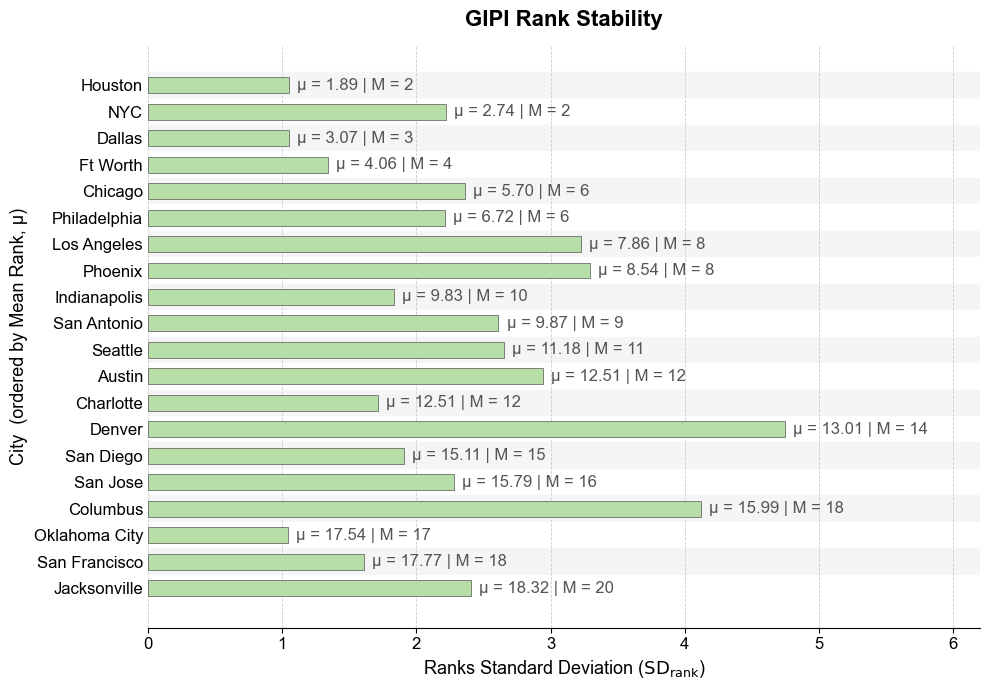

In [8]:

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Color bars by SD magnitude (low SD = green/stable, high SD = red/unstable)
cmap = cm.get_cmap('RdYlGn_r') 
#cmap = cm.get_cmap('YlGnBu') 
norm = mcolors.Normalize(vmin=df_sd["SD"].min(), vmax=df_sd["SD"].max())

# Alternating row shading behind the bars
n = len(df_sd)
for i in range(n):
    ax.axhspan(i - 0.5, i + 0.5,
               color='#f5f5f5' if i % 2 == 0 else 'white', zorder=0)

y_pos = np.arange(n)

bars = ax.barh(
    y_pos,
    df_sd["SD"],
    height=0.6,
    #color=[cmap(norm(v)) for v in df_sd["SD"]],
    color='#b8dea7', #other potential colors: #52b69a, #97c985, #6baed6 
    edgecolor='#555555',
    linewidth=0.5,
    zorder=2
)

# Mean rank value annotated at the right of each bar
for i, (_, row) in enumerate(df_sd.iterrows()):
    ax.text(
        row["SD"] + 0.06,
        i,
        f'μ = {row["Mean Rank"]:.2f} | M = {row["Median Rank"]:.0f}',
        va='center',
        fontsize=12,
        color='#555555'
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sd["City"], fontsize=12)
ax.invert_yaxis()   # top of chart = first in Classic GIPI order

ax.set_xlabel("Ranks Standard Deviation ($\mathrm{SD}_{\mathrm{rank}}$)", fontsize=13)
ax.set_ylabel("City  (ordered by Mean Rank, μ)", fontsize=13)
ax.set_title("GIPI Rank Stability", fontsize=16,
             fontweight='bold', pad=14)

ax.set_xlim(0, 6.2)
ax.xaxis.grid(True, linestyle='--', linewidth=0.6, color='#cccccc', zorder=1)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# # Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02)
# cbar.set_label(r'$\mathrm{SD}_{\mathrm{rank}}$  (← higher stability  |  lower stability →)', fontsize=13)
# cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
#plt.savefig('GIPI_sd_barplot.png', dpi=500, bbox_inches='tight')
plt.show()